Linear Regression Assignment
Elizabeth Soetan
WTF/DS/2024/0276

In [ ]:
#importing the libraries
import pandas as pd
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Loadng the datasets
df = pd.read_csv("/content/heart.csv")

In [ ]:
#Checking the dataset
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0.23
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0.37
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0.24
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0.28
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0.21


In [ ]:
#Checking the summaary of the dataset
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   float64
dtypes: float64(2), int64(12)
memory usage: 112.2 KB


In [ ]:
#Checking for null values
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [ ]:
#Checking for duplicated values
df.duplicated().sum()

55

In [ ]:
#Dropping the duplicated values
df.drop_duplicates (inplace=True)

Checking for Age distibution

<Axes: xlabel='age', ylabel='Count'>

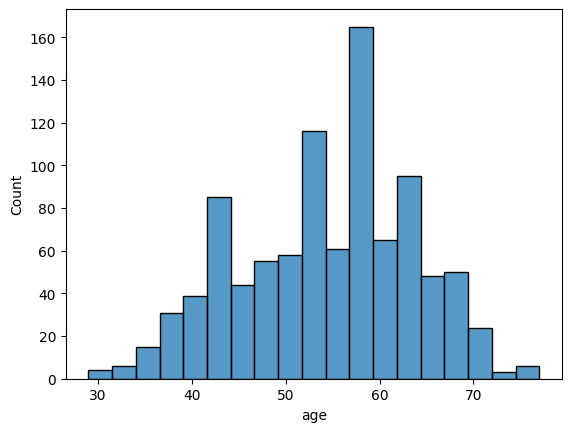

In [ ]:
sns.histplot(df.age)

In [ ]:
df['fbs'].value_counts()


0    824
1    146
Name: fbs, dtype: int64

In [ ]:
df['sex'].value_counts()

1    675
0    295
Name: sex, dtype: int64

In [ ]:
df["target"].unique()

array([0.23, 0.37, 0.24, 0.28, 0.21, 0.78, 0.17, 0.25, 0.87, 0.86, 0.85,
       0.2 , 0.79, 0.26, 0.83, 0.77, 0.71, 0.9 , 0.27, 0.8 , 0.38, 0.11,
       0.84, 0.39, 0.76, 0.88, 0.22, 0.75, 0.31, 0.74, 0.32, 0.7 , 0.3 ,
       0.29, 0.35, 0.14, 0.72, 0.18, 0.82, 0.12, 0.13, 0.73, 0.89, 0.16,
       0.33, 0.1 , 0.19, 0.81, 0.15, 0.4 , 0.36, 0.34])

<Axes: xlabel='sex', ylabel='age'>

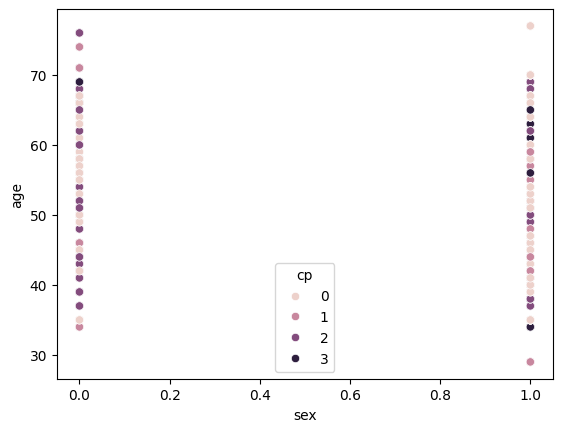

In [ ]:
sns.scatterplot(x='sex', y='age', data=df, hue ='cp')

<Axes: >

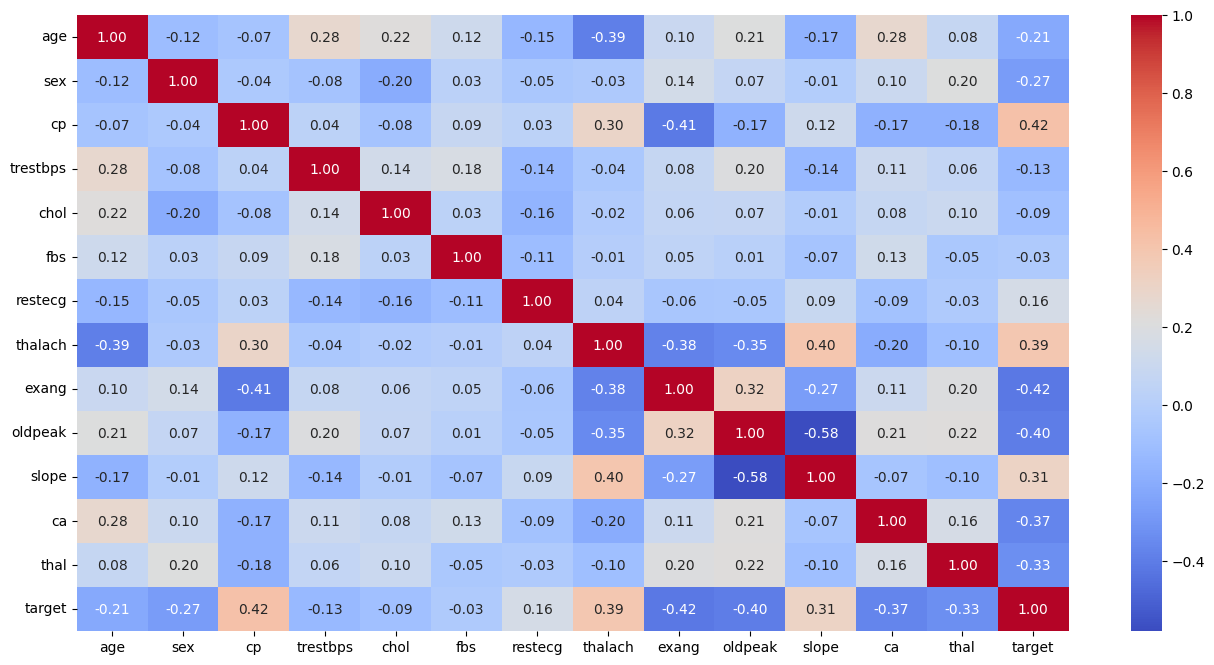

In [ ]:
#Checking the correlation between the dataset
corr = df.corr()
plt.figure(figsize=(16, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})

<Axes: xlabel='chol', ylabel='age'>

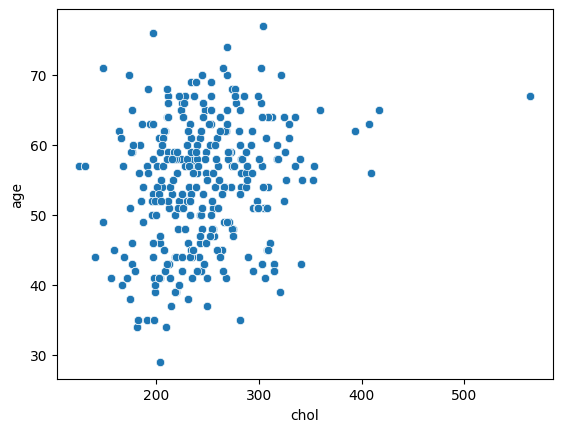

In [ ]:
sns.scatterplot(x='chol', y='age', data=df)

<Axes: xlabel='cp', ylabel='thalach'>

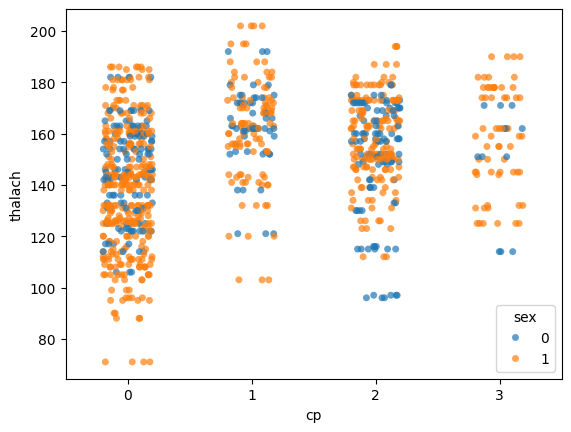

In [ ]:
sns.stripplot(data=df, x='cp', y='thalach', hue='sex', jitter=0.2,alpha=0.7)

<Axes: xlabel='cp', ylabel='target'>

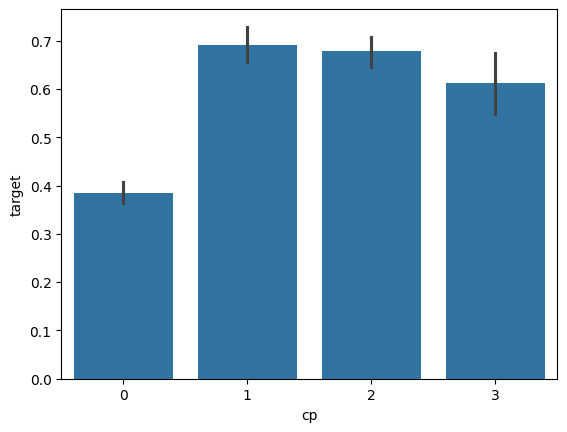

In [ ]:
sns.barplot(data=df, x='cp', y='target')

<Axes: xlabel='sex', ylabel='chol'>

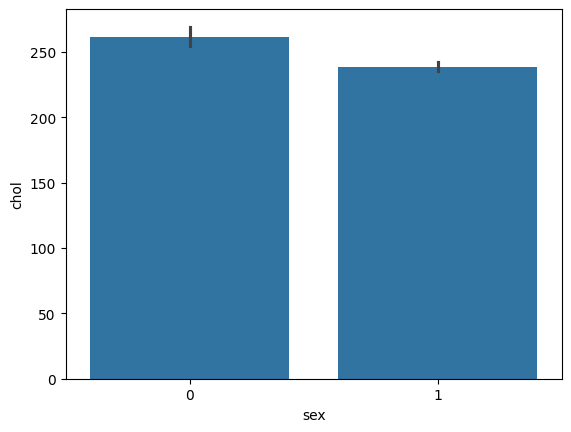

In [ ]:
sns.barplot(data=df, x='sex', y='chol')

<Axes: xlabel='sex', ylabel='exang'>

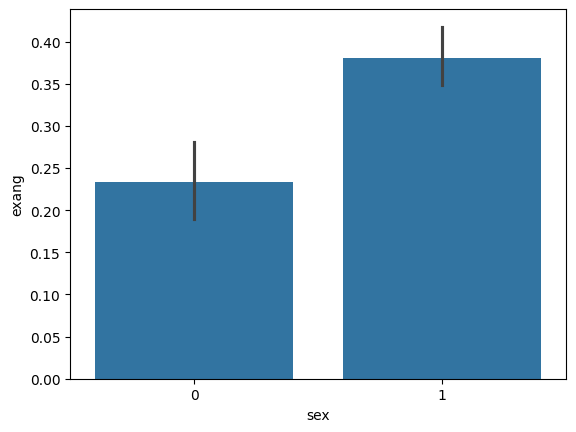

In [ ]:
sns.barplot(data=df, x='sex', y='exang')

<Axes: xlabel='exang', ylabel='target'>

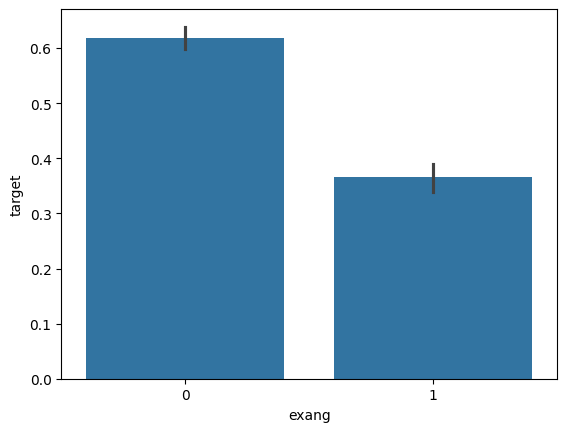

In [ ]:
sns.barplot(data=df, x='exang', y='target')

<Axes: xlabel='slope', ylabel='restecg'>

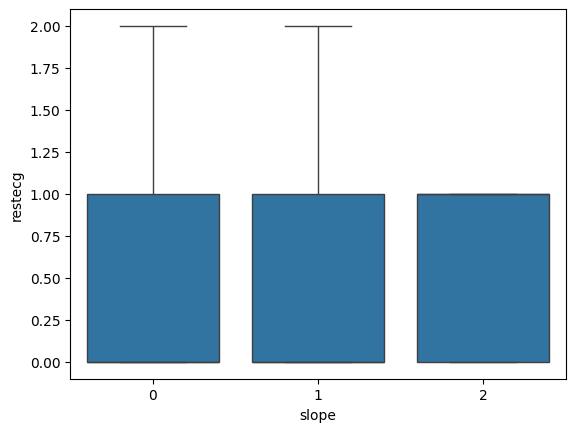

In [ ]:
sns.boxplot(data=df, x='slope', y='restecg')

In [ ]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')

<Axes: xlabel='cp', ylabel='target'>

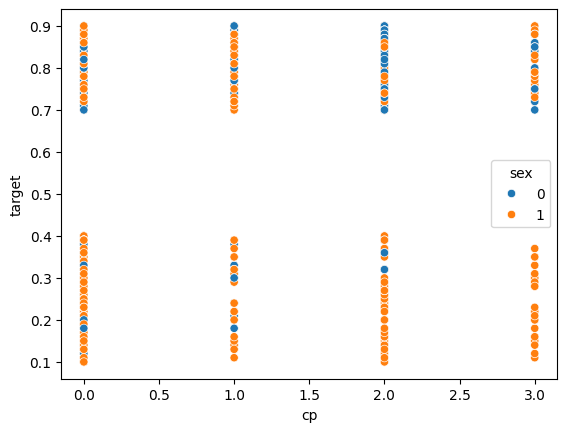

In [ ]:
sns.scatterplot(x='cp', y='target', data=df, hue ='sex')

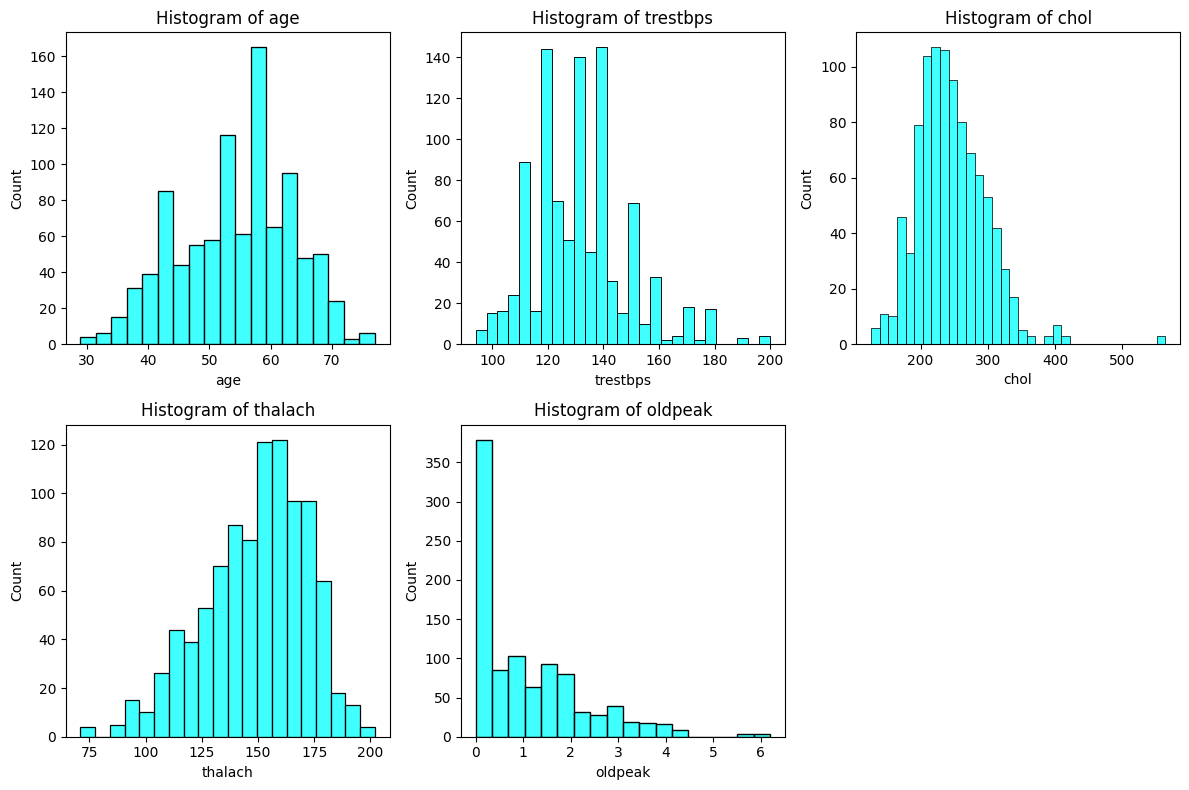

In [ ]:
#reating multiple histogram plots
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Create box plots for each numerical feature
plt.figure(figsize=(12, 8))
for i, feature in enumerate(numerical_features, 1):
    plt.subplot(2, 3, i)
    sns.histplot(x=df[feature], color='cyan')
    plt.title(f'Histogram of {feature}')

plt.tight_layout()

In [ ]:
df['target'].value_counts()

0.83    30
0.80    30
0.85    30
0.78    29
0.86    29
0.89    28
0.82    27
0.88    27
0.72    25
0.73    24
0.39    24
0.84    23
0.87    23
0.26    22
0.75    22
0.81    22
0.74    22
0.77    21
0.32    20
0.79    20
0.14    20
0.12    20
0.71    19
0.76    19
0.27    18
0.36    18
0.20    18
0.37    18
0.18    18
0.23    17
0.38    17
0.17    17
0.28    17
0.13    17
0.16    16
0.30    16
0.33    16
0.35    15
0.25    15
0.21    15
0.24    14
0.22    13
0.11    12
0.90    12
0.29    11
0.70    11
0.40    11
0.31    10
0.10     9
0.19     9
0.15     8
0.34     6
Name: target, dtype: int64

In [ ]:
#Creating a new column
df['new_target'] = df['target'].apply(lambda x: 1 if x >= 0.5 else 0)

In [ ]:
X=df.drop(columns=['target','new_target'])
y=df.new_target

In [ ]:
#importing a new library
from sklearn.model_selection import train_test_split

In [ ]:
#train_test_split function
X_train,X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [ ]:
lr=LinearRegression()

In [ ]:
#Training model
model =lr.fit(X_train, y_train)

In [ ]:
#Model train score
model.score(X_train, y_train)

0.5246995882072913

In [ ]:
#Moel test score
model.score(X_test, y_test)

0.4739044649645897

In [ ]:
#importing polynomialFeaatures library
from sklearn.preprocessing import PolynomialFeatures

In [ ]:
poly=PolynomialFeatures(2)

In [ ]:
X_trans= poly.fit_transform(X)

In [ ]:
#train_test_split function
X_train,X_test, y_train, y_test = train_test_split(X_trans, y, test_size=0.3, random_state=42)

In [ ]:
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
#Model train score
model.score(X_train, y_train)

0.7156470549603784

In [ ]:
#Model test score
model.score(X_test,y_test)

0.634349660047729